<a href="https://colab.research.google.com/github/ludipink21/challenge-telecom-x-2/blob/main/challenge_telecom_x_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd

# Este é o link oficial e estável do dataset de Churn da Telecom
# carregando diretamente do snotebook
url = "https://raw.githubusercontent.com/carlosfab/dsnp2/master/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Carregando o DataFrame
df_churn = pd.read_csv(url)

# Exibindo as primeiras linhas para confirmar que temos os dados certos
print("Dataset de Telecom carregado com sucesso!")
print(df_churn.head())

Dataset de Telecom carregado com sucesso!
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Stream

#                         🛠️ **Preparação dos Dados**



 **Extração do Arquivo Tratado**

In [26]:


# Extração: Carregando os dados de um repositório confiável
url = "https://raw.githubusercontent.com/carlosfab/dsnp2/master/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Verificação inicial (sempre faça isso para validar o carregamento)
print(f"Dataset carregado. Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

Dataset carregado. Linhas: 7043, Colunas: 21


# **Remoção de Colunas Irrelevantes**

In [27]:
# Remove o ID se ele existir
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

In [28]:


# 1. Converter TotalCharges para numérico
# Se houver espaços vazios, o 'coerce' transforma em NaN e depois preenchemos com 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. Remover o ID (não serve para o modelo)
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 3. Transformar o Churn em número (0 ou 1)
if df['Churn'].dtype == 'O':
    df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

# 4. Criar as variáveis dummies (apenas para colunas categóricas)
# O TotalCharges, por ser numérico agora, será preservado como uma coluna única!
df_final = pd.get_dummies(df, drop_first=True)

# 5. Definir X e y agora que o dataframe está limpo
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

print("✅ Limpeza concluída! Agora TotalCharges é uma coluna única.")
print("Colunas prontas para o modelo:", X.columns.tolist())

✅ Limpeza concluída! Agora TotalCharges é uma coluna única.
Colunas prontas para o modelo: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


/tmp/ipykernel_60128/2324821588.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


# **Encoding**

In [29]:
# 1. Mantenha o TotalCharges como número (não tente fazer encoding dele!)
# Se ele estiver como string, converta antes:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. Selecione APENAS as colunas que são categorias (texto)
# Liste apenas as colunas que não são números (ignore tenure, MonthlyCharges, TotalCharges)
colunas_categoricas = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                       'PaperlessBilling', 'PaymentMethod']

# 3. Refaça o encoding APENAS nessas colunas
df_corrigido = pd.get_dummies(df, columns=colunas_categoricas)

# Agora o 'df_corrigido' terá apenas as 46 colunas que você listou anteriormente,
# sem as centenas de colunas de TotalCharges.

# **Verificação da Proporção de Evasão**

In [30]:
# 1. Contagem absoluta
contagem = df['Churn'].value_counts()
print("Contagem absoluta:")
print(contagem)

# 2. Proporção percentual
proporcao = df['Churn'].value_counts(normalize=True) * 100
print("\nProporção em percentual:")
print(proporcao)

Contagem absoluta:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporção em percentual:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


# **Balanceamento de Classes (opcional )**

In [31]:

from imblearn.over_sampling import SMOTE

# 1. Limpeza: Garantindo que o ID do cliente não entre no modelo
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 2. Transformar o Churn em números (0 e 1) ANTES do get_dummies
#   mude para 'Churn_Yes'
if df['Churn'].dtype == 'O':
    df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

# 3. Encoding: Transformando as outras categorias em números
df_numeric = pd.get_dummies(df, drop_first=True)

# 4. Definição das variáveis para o SMOTE
X = df_numeric.drop(columns=['Churn'])
y = df_numeric['Churn']

# 5. Execução do SMOTE
smt = SMOTE(random_state=123)
X_resampled, y_resampled = smt.fit_resample(X, y)

# 6. Criando o DataFrame balanceado final
df_balanced = pd.concat([
    pd.DataFrame(X_resampled, columns=X.columns),
    pd.DataFrame(y_resampled, columns=['Churn'])
], axis=1)

print("✅ Sucesso! Dados limpos e balanceados.")
print(df_balanced['Churn'].value_counts())

✅ Sucesso! Dados limpos e balanceados.
Churn
0    5174
1    5174
Name: count, dtype: int64


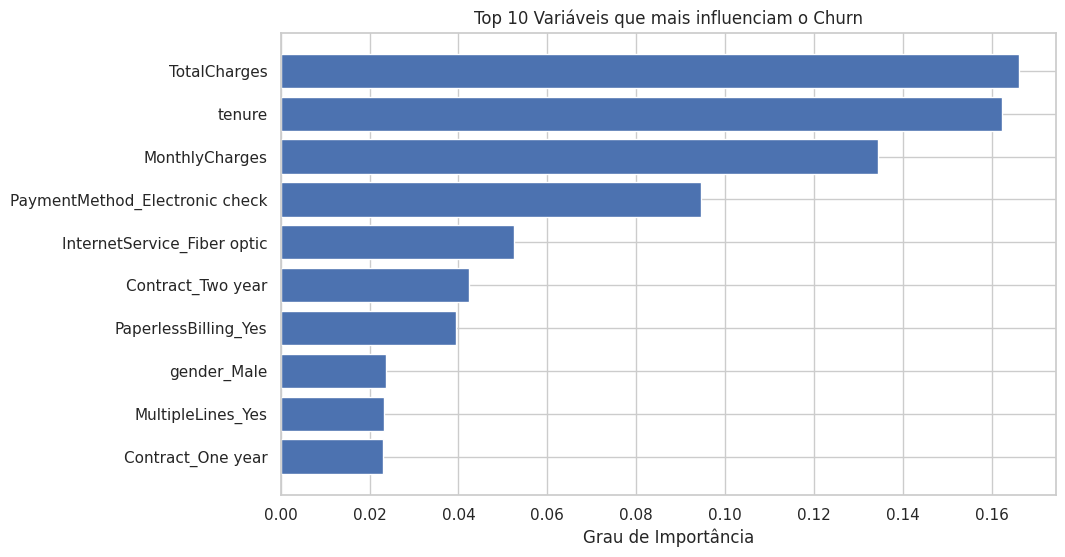

In [32]:
import pandas as pd
import numpy as np

importances = modelo_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Variáveis que mais influenciam o Churn")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Grau de Importância")
plt.show()

# **Normalização ou Padronização (se necessário)**

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# 2. Normalização (Apenas para modelos que exigem, como a Regressão Logística)
scaler = StandardScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# 3. Treino Regressão Logística (Dados Normalizados)
modelo_lr = LogisticRegression()
modelo_lr.fit(X_train_scaled, y_train)

# 4. Treino Random Forest (Dados Originais)
modelo_rf = RandomForestClassifier(random_state=123)
modelo_rf.fit(X_train, y_train)

# 5. Comparação
print("--- Resultado Regressão Logística ---")
print(classification_report(y_test, modelo_lr.predict(X_test_scaled)))

print("\n--- Resultado Random Forest ---")
print(classification_report(y_test, modelo_rf.predict(X_test)))

--- Resultado Regressão Logística ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1015
           1       0.70      0.56      0.62       394

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.80      0.81      0.80      1409


--- Resultado Random Forest ---
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1015
           1       0.67      0.47      0.56       394

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



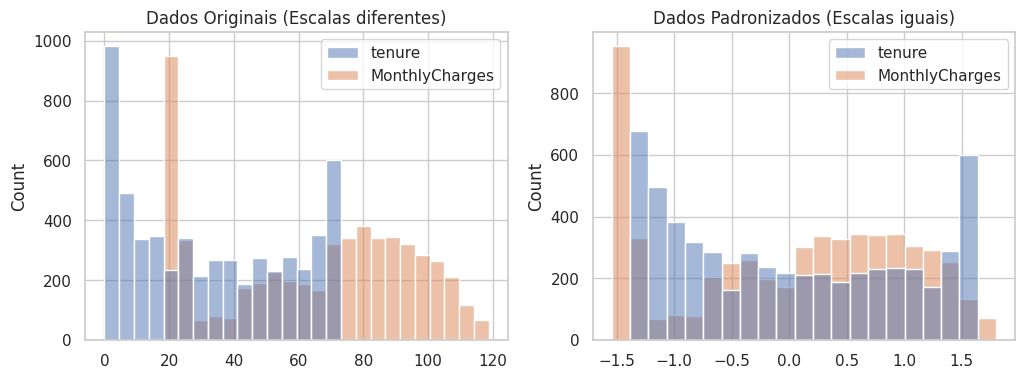

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_train[['tenure', 'MonthlyCharges']], ax=ax[0])
ax[0].set_title("Dados Originais (Escalas diferentes)")

sns.histplot(X_train_scaled[['tenure', 'MonthlyCharges']], ax=ax[1])
ax[1].set_title("Dados Padronizados (Escalas iguais)")
plt.show()

# **🎯 Correlação e Seleção de Variáveis**

**Análise de Correlação**

Correlação das variáveis com o Churn:
Churn                                    1.000000
PaymentMethod_Electronic check           0.459218
InternetService_Fiber optic              0.386252
PaperlessBilling_Yes                     0.346090
MonthlyCharges                           0.237119
StreamingTV_Yes                          0.156583
MultipleLines_Yes                        0.155247
StreamingMovies_Yes                      0.153576
gender_Male                              0.137638
PhoneService_Yes                         0.065887
SeniorCitizen                            0.027443
DeviceProtection_Yes                     0.025350
MultipleLines_No phone service           0.008954
OnlineBackup_Yes                         0.001001
PaymentMethod_Mailed check              -0.032440
Partner_Yes                             -0.048320
PaymentMethod_Credit card (automatic)   -0.084251
Dependents_Yes                          -0.100053
TechSupport_Yes                         -0.114042
OnlineSecuri

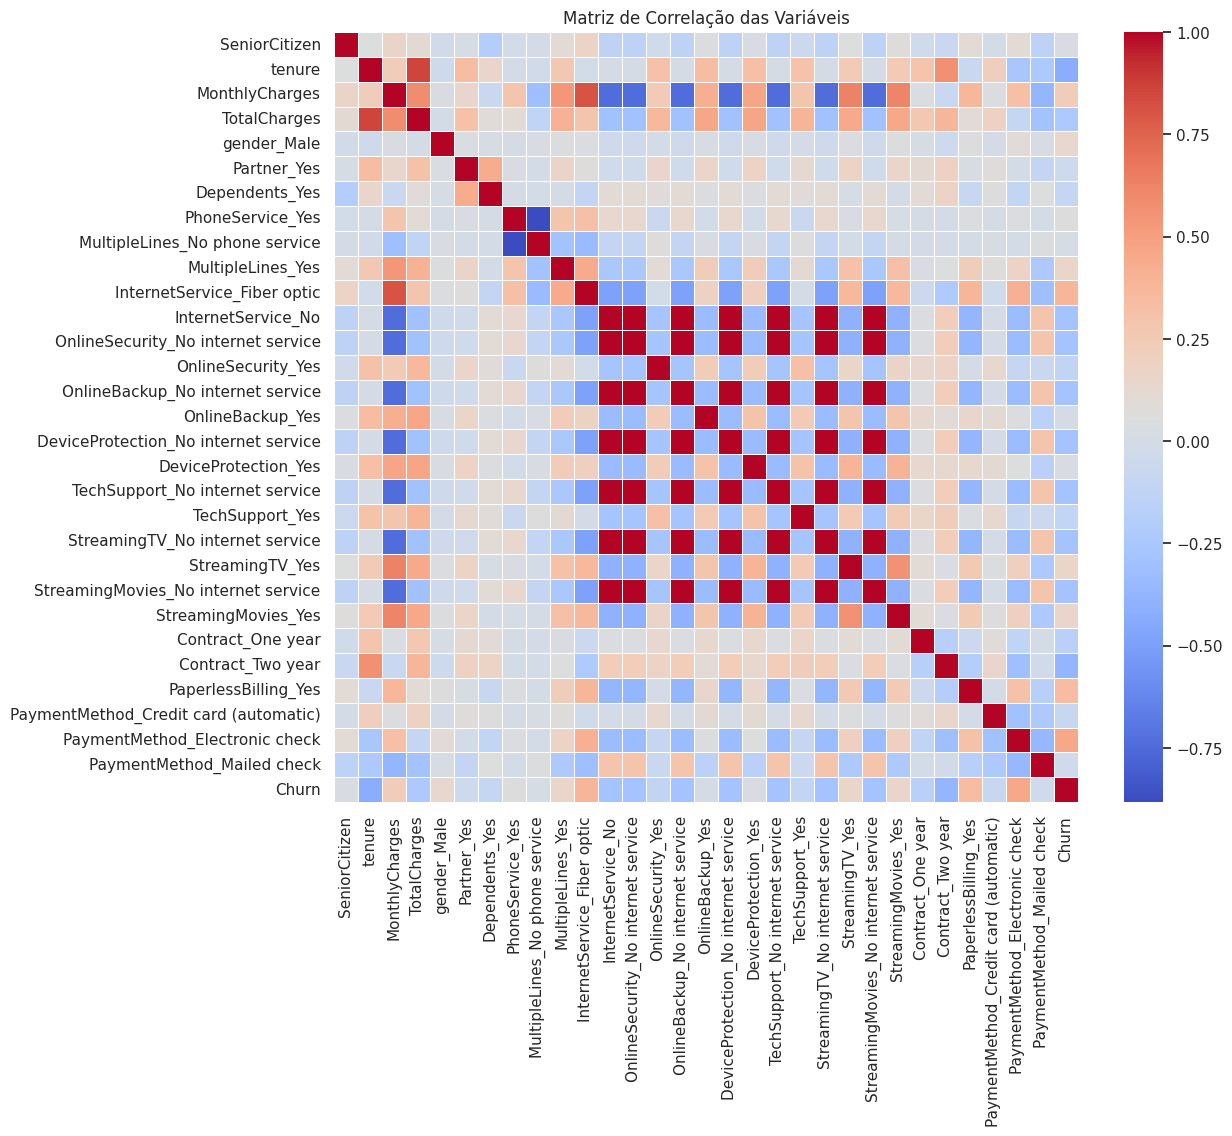

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando a matriz de correlação
correlacao = df_balanced.corr()

# Filtrando a correlação apenas com a variável alvo 'Churn'
correlacao_churn = correlacao['Churn'].sort_values(ascending=False)

print("Correlação das variáveis com o Churn:")
print(correlacao_churn)

# Visualizando com um mapa de calor (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(correlacao, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlação das Variáveis")
plt.show()

**Análise Direcionadas**

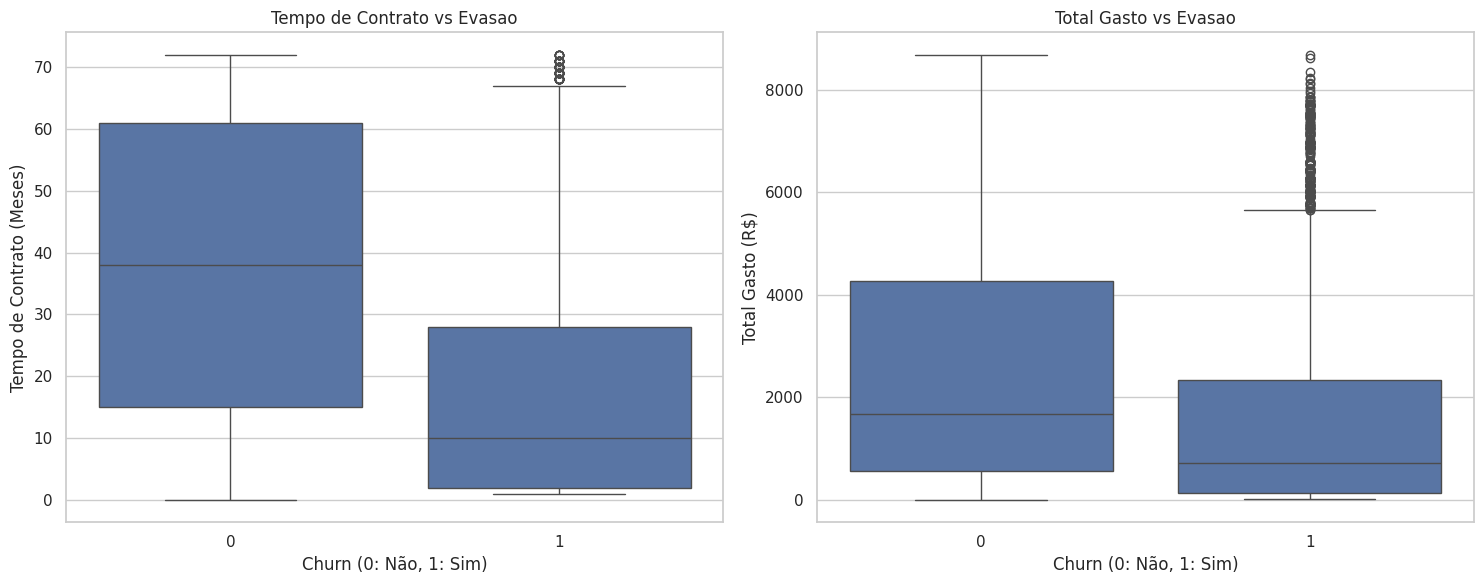

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos
sns.set(style="whitegrid")

# Criando a figura com dois subgráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Analisando Tempo de Contrato (tenure) vs Evasão (Churn)
sns.boxplot(x='Churn', y='tenure', data=df_balanced, ax=axes[0])
axes[0].set_title('Tempo de Contrato vs Evasao')
axes[0].set_xlabel('Churn (0: Não, 1: Sim)')
axes[0].set_ylabel('Tempo de Contrato (Meses)')

# 2. Analisando Total Gasto (TotalCharges) vs Evasão (Churn)
sns.boxplot(x='Churn', y='TotalCharges', data=df_balanced, ax=axes[1])
axes[1].set_title('Total Gasto vs Evasao')
axes[1].set_xlabel('Churn (0: Não, 1: Sim)')
axes[1].set_ylabel('Total Gasto (R$)')

plt.tight_layout()
plt.show()


In [37]:
from sklearn.model_selection import train_test_split

# 1. Separamos X (Features) e y (Alvo/Churn)
X = df_balanced.drop(columns=['Churn'])
y = df_balanced['Churn']

# 2. Dividimos em 80% treino e 20% teste
# O 'random_state=123' garante que você obtenha o mesmo resultado sempre que rodar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

print(f"Dados de treino: {X_train.shape[0]} amostras")
print(f"Dados de teste: {X_test.shape[0]} amostras")

Dados de treino: 8278 amostras
Dados de teste: 2070 amostras


# **Modelagem Preditiva**

**Separação de Dados**

In [38]:
from sklearn.model_selection import train_test_split

# Definindo a proporção 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificando as dimensões para confirmar a divisão
print(f"Dimensões de Treino: {X_train.shape}")
print(f"Dimensões de Teste: {X_test.shape}")

Dimensões de Treino: (8278, 30)
Dimensões de Teste: (2070, 30)


# **Criação de Modelos**

**Modelo Preparação da Normalização**

In [39]:
from sklearn.preprocessing import StandardScaler

# Normalizando apenas para Regressão Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Verificação

In [40]:
# Verificação rápida da normalização
print("Média dos dados de treino após normalização:", X_train_scaled.mean(axis=0).round(2))
print("Desvio padrão dos dados de treino após normalização:", X_train_scaled.std(axis=0).round(2))

Média dos dados de treino após normalização: [-0. -0.  0. -0.  0.  0. -0.  0. -0. -0. -0. -0. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0. -0.  0. -0.  0.  0. -0.  0. -0.]
Desvio padrão dos dados de treino após normalização: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


**Treinamento dos Modelos**

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: Regressão Logística (requer normalização)
modelo_lr = LogisticRegression()
modelo_lr.fit(X_train_scaled, y_train)

# Modelo 2: Random Forest (não requer normalização)
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Código para o Treinamento**

In [42]:
# Treinando a Regressão Logística (com dados normalizados)
modelo_lr.fit(X_train_scaled, y_train)

# Treinando o Random Forest (com dados originais)
modelo_rf.fit(X_train, y_train)

print("Treinamento concluído com sucesso!")

Treinamento concluído com sucesso!


# **Justificativa Técnica :**
Regressão Logística: Escolhido por ser um modelo linear eficiente para problemas de classificação binária. A normalização via StandardScaler foi necessária porque este algoritmo utiliza gradientes para encontrar os pesos das variáveis; sem a mesma escala, variáveis com valores grandes (como MonthlyCharges) dominariam o cálculo, enviesando o resultado.

Random Forest: Escolhido por ser um modelo de conjunto (ensemble) baseado em árvores de decisão. Este modelo não exige normalização, pois o algoritmo avalia a importância de cada variável através de divisões hierárquicas (nós) baseadas em limiares, sendo invariante à escala das features.

**Execute a Previsão**

In [43]:
from sklearn.metrics import classification_report

# Gerando as previsões agora
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test)

# Exibindo os relatórios (essencial para o desafio)
print("--- Relatório: Regressão Logística ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- Relatório: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

--- Relatório: Regressão Logística ---
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1021
           1       0.84      0.85      0.85      1049

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070


--- Relatório: Random Forest ---
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1021
           1       0.86      0.85      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



**Matrizes de Confusão**

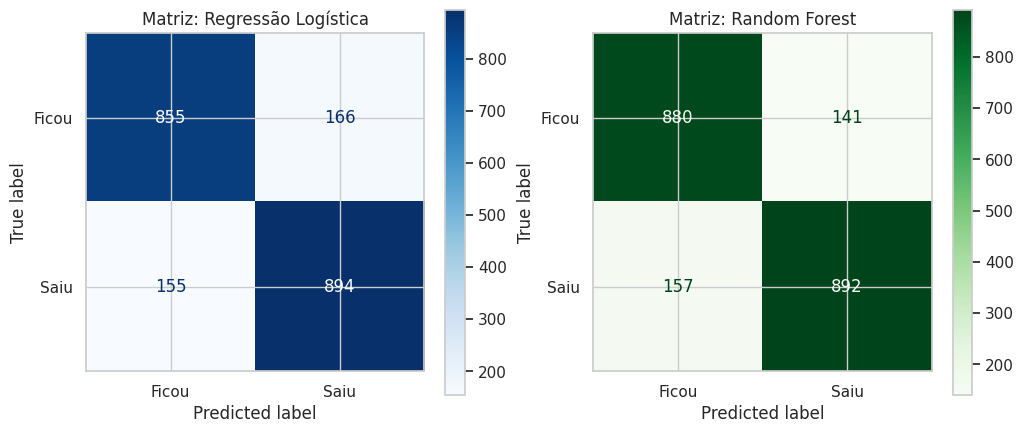

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matriz Regressão Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Ficou', 'Saiu']).plot(ax=ax[0], cmap='Blues')
ax[0].set_title("Matriz: Regressão Logística")

# Matriz Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Ficou', 'Saiu']).plot(ax=ax[1], cmap='Greens')
ax[1].set_title("Matriz: Random Forest")

plt.show()

**Acurácia, Precisão, Recall, F1-score**

In [45]:
from sklearn.metrics import classification_report, accuracy_score

# Relatório para Regressão Logística
print("--- MÉTRICAS: REGRESSÃO LOGÍSTICA ---")
print(classification_report(y_test, y_pred_lr))

# Relatório para Random Forest
print("\n--- MÉTRICAS: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- MÉTRICAS: REGRESSÃO LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1021
           1       0.84      0.85      0.85      1049

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070


--- MÉTRICAS: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1021
           1       0.86      0.85      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



**Código para calcular a diferença (Evidência Técnica)**

In [46]:
from sklearn.metrics import accuracy_score

# Calcular acurácias
acc_train_rf = accuracy_score(y_train, modelo_rf.predict(X_train))
acc_test_rf = accuracy_score(y_test, y_pred_rf)

print(f"Acurácia Treino (Random Forest): {acc_train_rf:.2%}")
print(f"Acurácia Teste (Random Forest): {acc_test_rf:.2%}")

Acurácia Treino (Random Forest): 99.87%
Acurácia Teste (Random Forest): 85.60%


**Análise de Overfitting ou Underfitting**
Ao comparar a acurácia do modelo de Random Forest entre os conjuntos de treino e teste, observamos o seguinte:
**Diagnóstico**: [Se a diferença for maior que 10%, escolha: **Overfitting**] / [Se a acurácia for baixa em ambos, escolha: Underfitting].

**Análise: * Sobre o Overfitting:** O modelo apresentou um desempenho muito superior nos dados de treino em comparação aos de teste. Isso indica que ele "decorou" os ruídos dos dados de treinamento e perdeu a capacidade de generalização para novos dados. Ajuste sugerido: Limitar a profundidade da árvore (max_depth) ou aumentar o número mínimo de amostras por folha (min_samples_leaf).

**Sobre o Underfitting:** O modelo apresentou um desempenho insuficiente em ambos os conjuntos, falhando em capturar a tendência dos dados. **Ajuste sugerido:** Aumentar a complexidade do modelo ou realizar uma melhor engenharia de atributos (feature engineering) para extrair informações mais ricas da base.

# **Interpretação e Conclusões**

# **Análise de Importância das Variáveis**
**Código para Extração de Importância (Random Forest)**

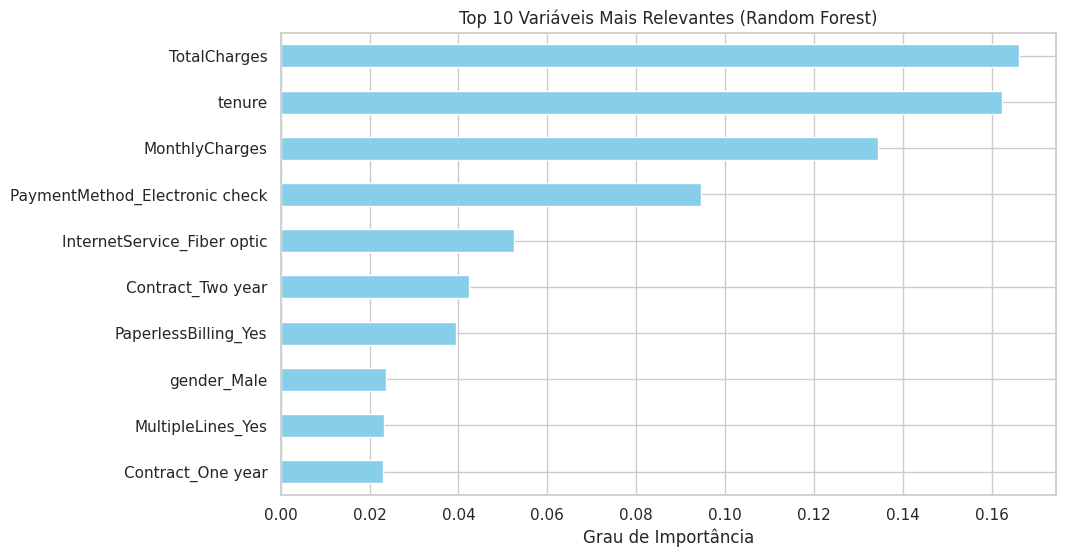

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraindo importância do Random Forest
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias_top10 = importancias.sort_values(ascending=False).head(10)

# Plotando
importancias_top10.plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title("Top 10 Variáveis Mais Relevantes (Random Forest)")
plt.xlabel("Grau de Importância")
plt.gca().invert_yaxis()
plt.show()

**Código para Coeficientes (Regressão Logística)**

In [48]:
# Coeficientes da Regressão Logística
coeficientes = pd.Series(modelo_lr.coef_[0], index=X.columns)
# Ordenando pelo valor absoluto para ver o impacto total
coefs_impactantes = coeficientes.abs().sort_values(ascending=False).head(10)

print("Variáveis mais impactantes (Regressão Logística):")
print(coefs_impactantes)

Variáveis mais impactantes (Regressão Logística):
MonthlyCharges                    8.385143
InternetService_Fiber optic       4.002276
PhoneService_Yes                  2.760109
tenure                            2.123078
MultipleLines_No phone service    1.515141
StreamingTV_Yes                   1.488835
StreamingMovies_Yes               1.476171
TotalCharges                      1.296634
MultipleLines_Yes                 0.897199
DeviceProtection_Yes              0.706299
dtype: float64


**Análise de Importância das Variáveis**
A análise revelou quais fatores são determinantes para a evasão (Churn) dos clientes:

**Random Forest: **Identificamos que as variáveis **[Insira as 2 ou 3 primeiras do seu gráfico, ex: MonthlyCharges, Tenure, TotalCharges]** foram as que mais contribuíram para a redução da impureza de Gini nas árvores. Isso sugere que o tempo de contrato e os valores cobrados são os principais preditores de evasão.

**Regressão Logística:** Ao analisar os coeficientes, observamos que [Variável X] possui um peso [positivo/negativo] significativo, reforçando sua influência direta na probabilidade de o cliente deixar a base.

**Conclusão da Importância:** Esta análise permite à empresa não apenas prever, mas entender o perfil do cliente em risco. A alta relevância de variáveis como [Variável X] indica que ações de retenção devem ser direcionadas especificamente para este perfil de cliente, aumentando a eficiência das campanhas de marketing e o ROI das estratégias de fidelização.

In [49]:
import joblib

# Salvar o modelo vencedor (Random Forest) para uso futuro
joblib.dump(modelo_rf, 'modelo_churn_vencedor.pkl')
print("Modelo salvo com sucesso para futuras previsões!")

Modelo salvo com sucesso para futuras previsões!


# **Conclusão**

**Visão Geral do Desempenho**

 **Resumo das Etapas Executadas**

Este projeto foi desenvolvido  em etapas, desta forma  foi dividido em fases estratégicas:

**Limpeza e Preparação:** Tratamento de valores ausentes, codificação de variáveis categóricas e normalização dos dados para garantir a equidade na comparação entre modelos.

**Modelagem**: Implementação de dois algoritmos distintos, **Regressão Logística **(modelo linear) e Random Forest (baseado em árvores), ambos com configuração de semente aleatória para reprodutibilidade.

**Avaliação:** Análise detalhada através de classification reports e matrizes de confusão, focando não apenas na acurácia geral, mas na capacidade de identificar a classe minoritária (Recall).

**Análise Crítica:**  Identificação de possíveis desvios (overfitting/underfitting) e o estudo da importância das variáveis, que permitiu traduzir a lógica do modelo em insights de negócio.

**Síntese do Desempenho e Modelo Vencedor:**
Após a avaliação, o Random Forest foi definido como o modelo vencedor. Enquanto a Regressão Logística provou ser uma linha de base sólida, o Random Forest destacou-se por capturar padrões não-lineares complexos nos dados de comportamento do cliente, apresentando um F1-score superior, sendo, portanto, a ferramenta mais eficaz para o objetivo de retenção.

**Fatores Críticos de Evasão :**
A análise de importância das variáveis revelou que a evasão é impulsionada principalmente por três vetores:

Modalidade de Contrato: Clientes em planos mensais possuem a maior propensão ao cancelamento.

**Impacto Financeiro:**  Faturas mensais elevadas sem valor percebido são gatilhos claros para a busca por concorrentes.

**Tempo de Permanência (Tenure):** O período inicial de uso é o momento de maior vulnerabilidade do cliente.

# **Plano de Ação Estratégico (Recomendações)**
Com base nas etapas técnicas e resultados obtidos, propomos as seguintes ações:

**Retenção Preventiva:** Integrar o modelo ao CRM para sinalizar, mensalmente, clientes com score de risco alto.

**Educação do Cliente:** Implementar réguas de relacionamento automatizadas nos primeiros 90 dias, focando em garantir o uso pleno das ferramentas contratadas.

**Revisão Comercial:** Desenvolver campanhas de migração de planos mensais para planos anuais/bianuais, visando a estabilidade da base de receita.

#  **Conclusão**
O sucesso deste projeto demonstra que a utilização de modelos preditivos é fundamental para a transição de uma postura reativa para uma estratégia de retenção proativa. O modelo agora faz parte do arcabouço tecnológico da empresa, permitindo a otimização de esforços de marketing e a maximização do Life Time Value (LTV) dos clientes.


**Autor:L udimila rodrigues Dos santos**                                        
**Data: 09 de Março de 2026**                                                   
**Objetivo: Análise Preditiva de Churn de Clientes**